### 1. Imports & Config

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, 
                           accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, roc_curve, auc)
import shap
import joblib
from datetime import datetime

OUTPUT_DIR = "outputs"
FIGURES_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

###  2. Load Dataset

In [33]:
df = pd.read_csv(r"D:\My_Project\Analyse\Student Performance Analysis\data\row\student.csv", encoding='latin1')
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (30641, 15)


,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


### 3. Data Inspectio

In [34]:
df.info()
display(df.describe())
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"Duplicate rows: {df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


EthnicGroup            1840
ParentEduc             1845
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
dtype: int64
Duplicate rows: 0


### 4. Data Cleaning 

In [35]:
df = df.drop_duplicates()
print(f"Duplicates removed. New shape: {df.shape}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

for col in num_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        print(f"Filling {col} with median: {median_val}")
        df[col].fillna(median_val, inplace=True)

for col in cat_cols:
    if df[col].isna().sum() > 0:
        mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else "Unknown"
        print(f"Filling {col} with mode: {mode_val}")
        df[col].fillna(mode_val, inplace=True)

def clip_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_before = ((series < lower) | (series > upper)).sum()
    if outliers_before > 0:
        print(f"  {series.name}: {outliers_before} outliers clipped ({lower:.2f} to {upper:.2f})")
    
    return series.clip(lower, upper)

for col in num_cols:
    if col != 'Unnamed: 0':
        df[col] = clip_outliers(df[col])

cleaned_path = os.path.join(OUTPUT_DIR, "cleaned_student.csv")
df.to_csv(cleaned_path, index=False)

print(f"Missing values after treatment: {df.isnull().sum().sum()}")
print(f"Dataset saved to: {cleaned_path}")
print(f"Final shape: {df.shape}")

Duplicates removed. New shape: (30641, 15)
Numeric columns: ['Unnamed: 0', 'NrSiblings', 'MathScore', 'ReadingScore', 'WritingScore']
Categorical columns: ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans', 'WklyStudyHours']
Filling NrSiblings with median: 2.0
Filling EthnicGroup with mode: group C
Filling ParentEduc with mode: some college
Filling TestPrep with mode: none
Filling ParentMaritalStatus with mode: married
Filling PracticeSport with mode: sometimes
Filling IsFirstChild with mode: yes
Filling TransportMeans with mode: school_bus
Filling WklyStudyHours with mode: 5 - 10
  NrSiblings: 291 outliers clipped (-2.00 to 6.00)
  MathScore: 76 outliers clipped (23.00 to 111.00)
  ReadingScore: 90 outliers clipped (27.50 to 111.50)
  WritingScore: 109 outliers clipped (26.50 to 110.50)
Missing values after treatment: 0
Dataset saved to: outputs\cleaned_student.csv
Final shape: (30641, 15)


### 5. Feature Engineering

In [36]:
score_cols = ['MathScore', 'ReadingScore', 'WritingScore']
df["AverageScore"] = df[score_cols].mean(axis=1)
df["TotalScore"] = df[score_cols].sum(axis=1)

def get_performance_category(avg_score):
    if avg_score >= 90:
        return "Excellent"
    elif avg_score >= 80:
        return "Very Good"
    elif avg_score >= 70:
        return "Good"
    elif avg_score >= 60:
        return "Average"
    elif avg_score >= 50:
        return "Below Average"
    else:
        return "Poor"

df["PerformanceCategory"] = df["AverageScore"].apply(get_performance_category)
df["StrongestSubject"] = df[score_cols].idxmax(axis=1).str.replace('Score', '')
df["WeakestSubject"] = df[score_cols].idxmin(axis=1).str.replace('Score', '')
df["ScoreBalance"] = df[score_cols].std(axis=1)
df["HighPerformer"] = (df["AverageScore"] >= 80).astype(int)

study_hours_map = {'< 5': 2.5, '5 - 10': 7.5, '> 10': 12.5}
df["WklyStudyHours_Numeric"] = df["WklyStudyHours"].map(study_hours_map)

def sibling_category(n):
    if n == 0:
        return "Only Child"
    elif n == 1:
        return "One Sibling"
    elif n <= 3:
        return "2-3 Siblings"
    else:
        return "4+ Siblings"

df["SiblingCategory"] = df["NrSiblings"].apply(sibling_category)

engineered_path = os.path.join(OUTPUT_DIR, "engineered_student.csv")
df.to_csv(engineered_path, index=False)

print(f"New features created: {len(df.columns) - 15} additional columns")
print(f"Engineered dataset saved to: {engineered_path}")
print("\nNew features preview:")
new_features = ['AverageScore', 'TotalScore', 'PerformanceCategory', 'StrongestSubject', 
               'WeakestSubject', 'ScoreBalance', 'HighPerformer', 'WklyStudyHours_Numeric', 'SiblingCategory']
display(df[new_features].head())


New features created: 9 additional columns
Engineered dataset saved to: outputs\engineered_student.csv

New features preview:


,AverageScore,TotalScore,PerformanceCategory,StrongestSubject,WeakestSubject,ScoreBalance,HighPerformer,WklyStudyHours_Numeric,SiblingCategory
0,72.000000,216.0,Good,Writing,Math,1.732051,0,2.5,2-3 Siblings
1,82.333333,247.0,Very Good,Reading,Math,11.590226,1,7.5,Only Child
2,90.333333,271.0,Excellent,Reading,Math,3.055050,1,2.5,4+ Siblings
3,47.666667,143.0,Poor,Reading,Writing,7.371115,0,7.5,One Sibling
4,76.333333,229.0,Good,Reading,Writing,1.527525,0,7.5,Only Child


### 6. Exploratory Data Analysis

Selected target: AverageScore
Classification target created. Class distribution: {1: 15465, 0: 15176}


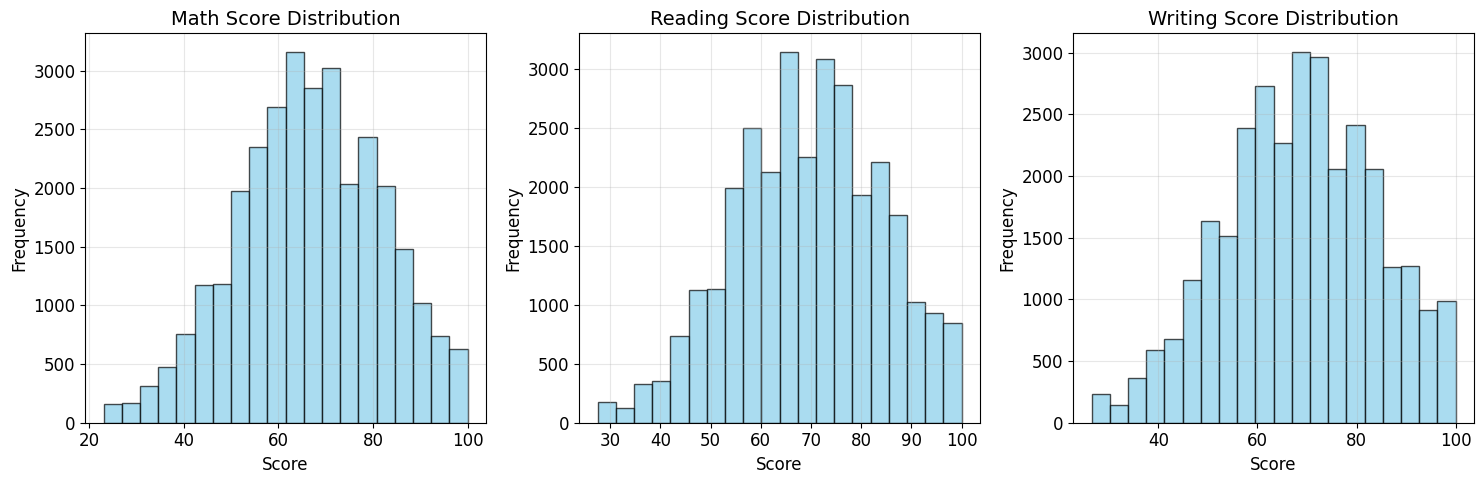

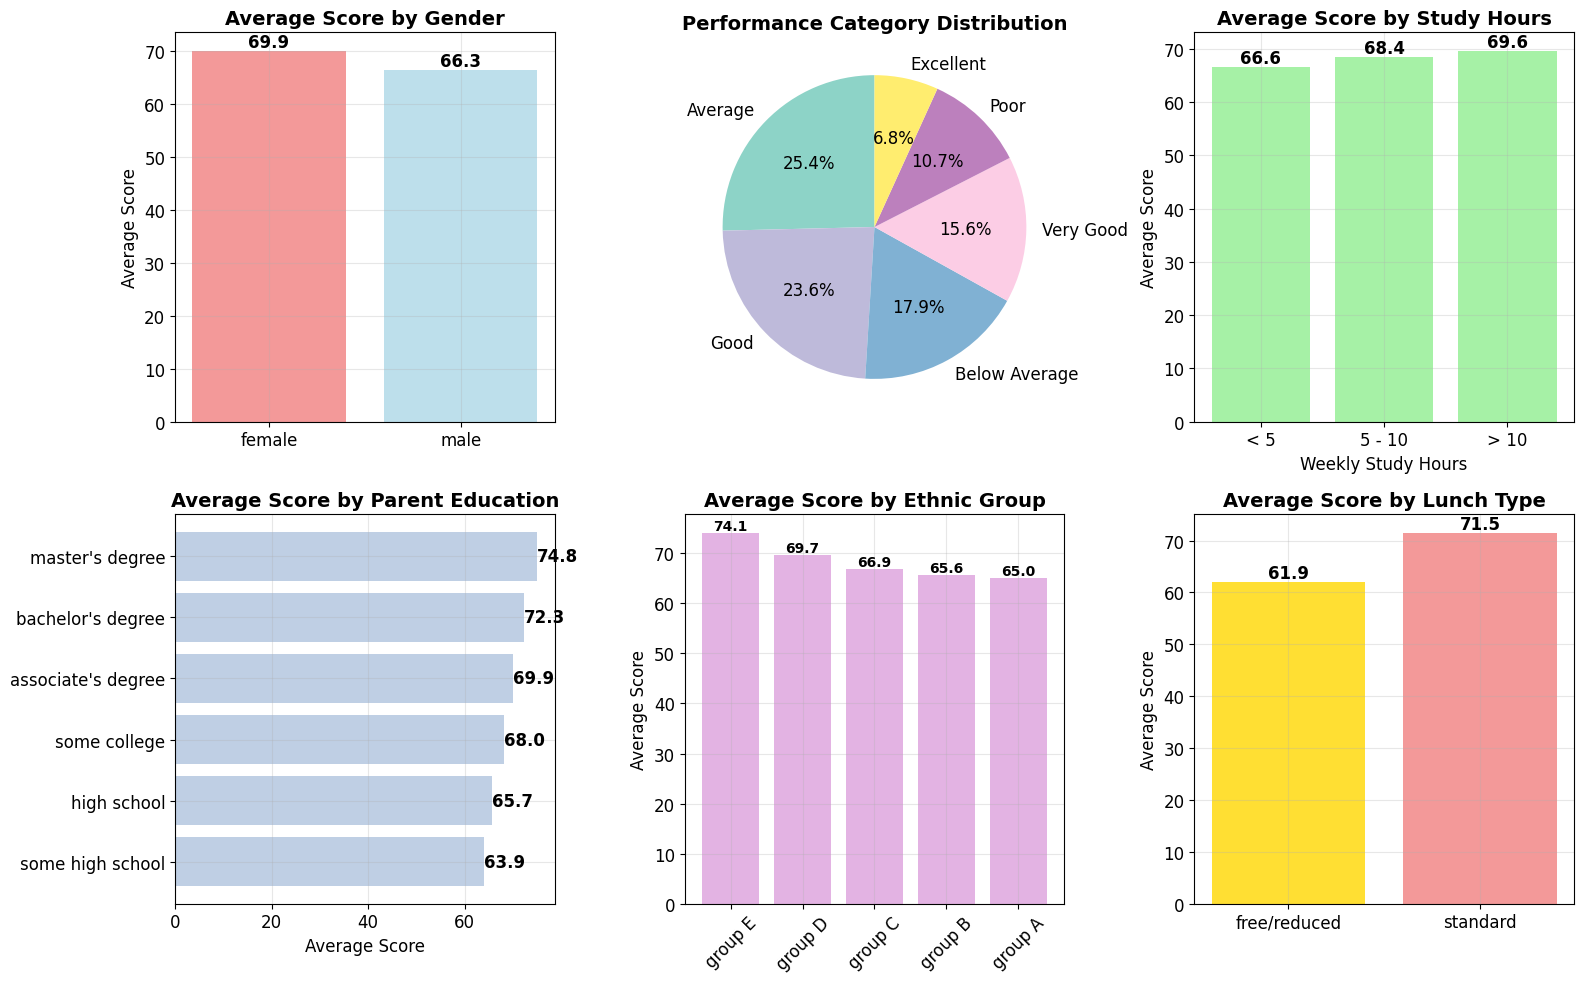

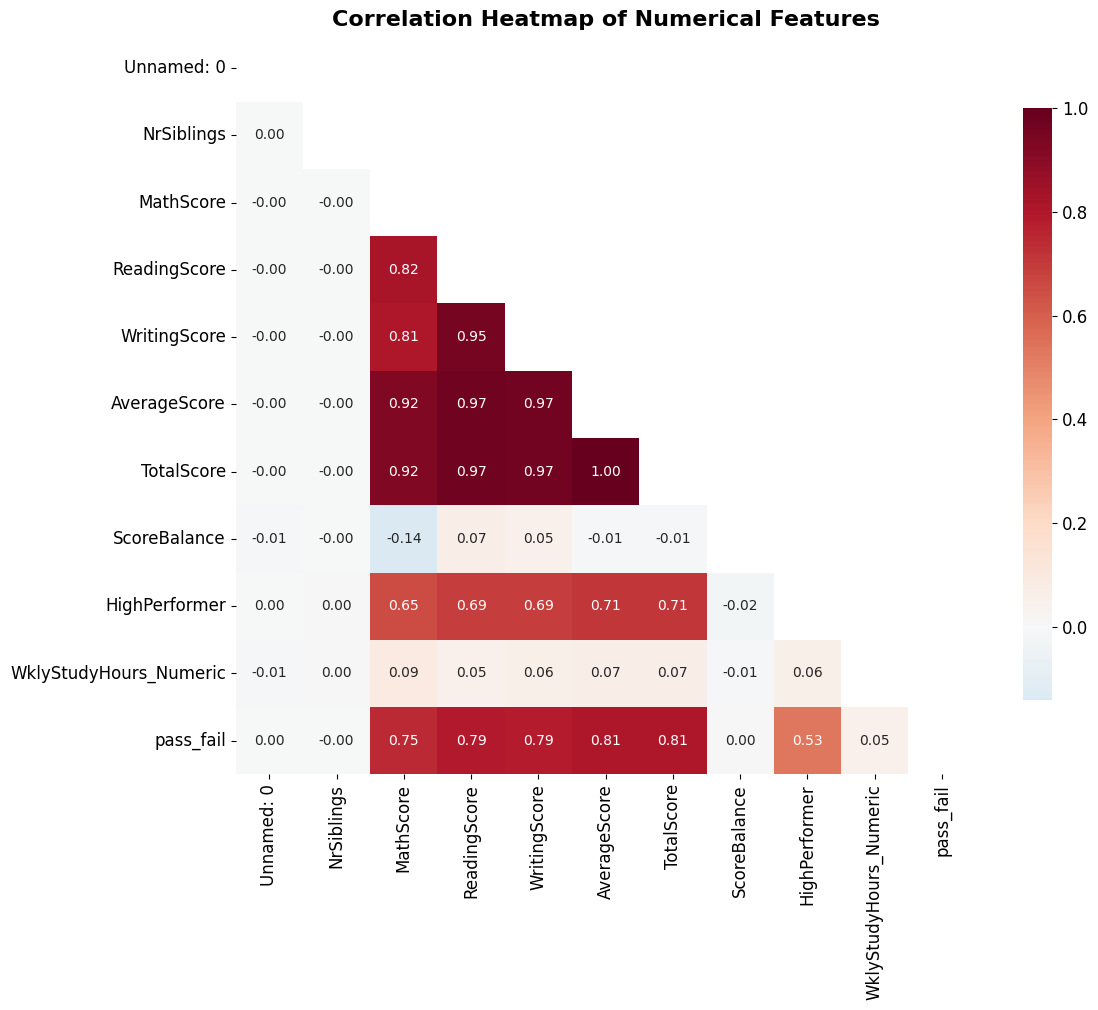

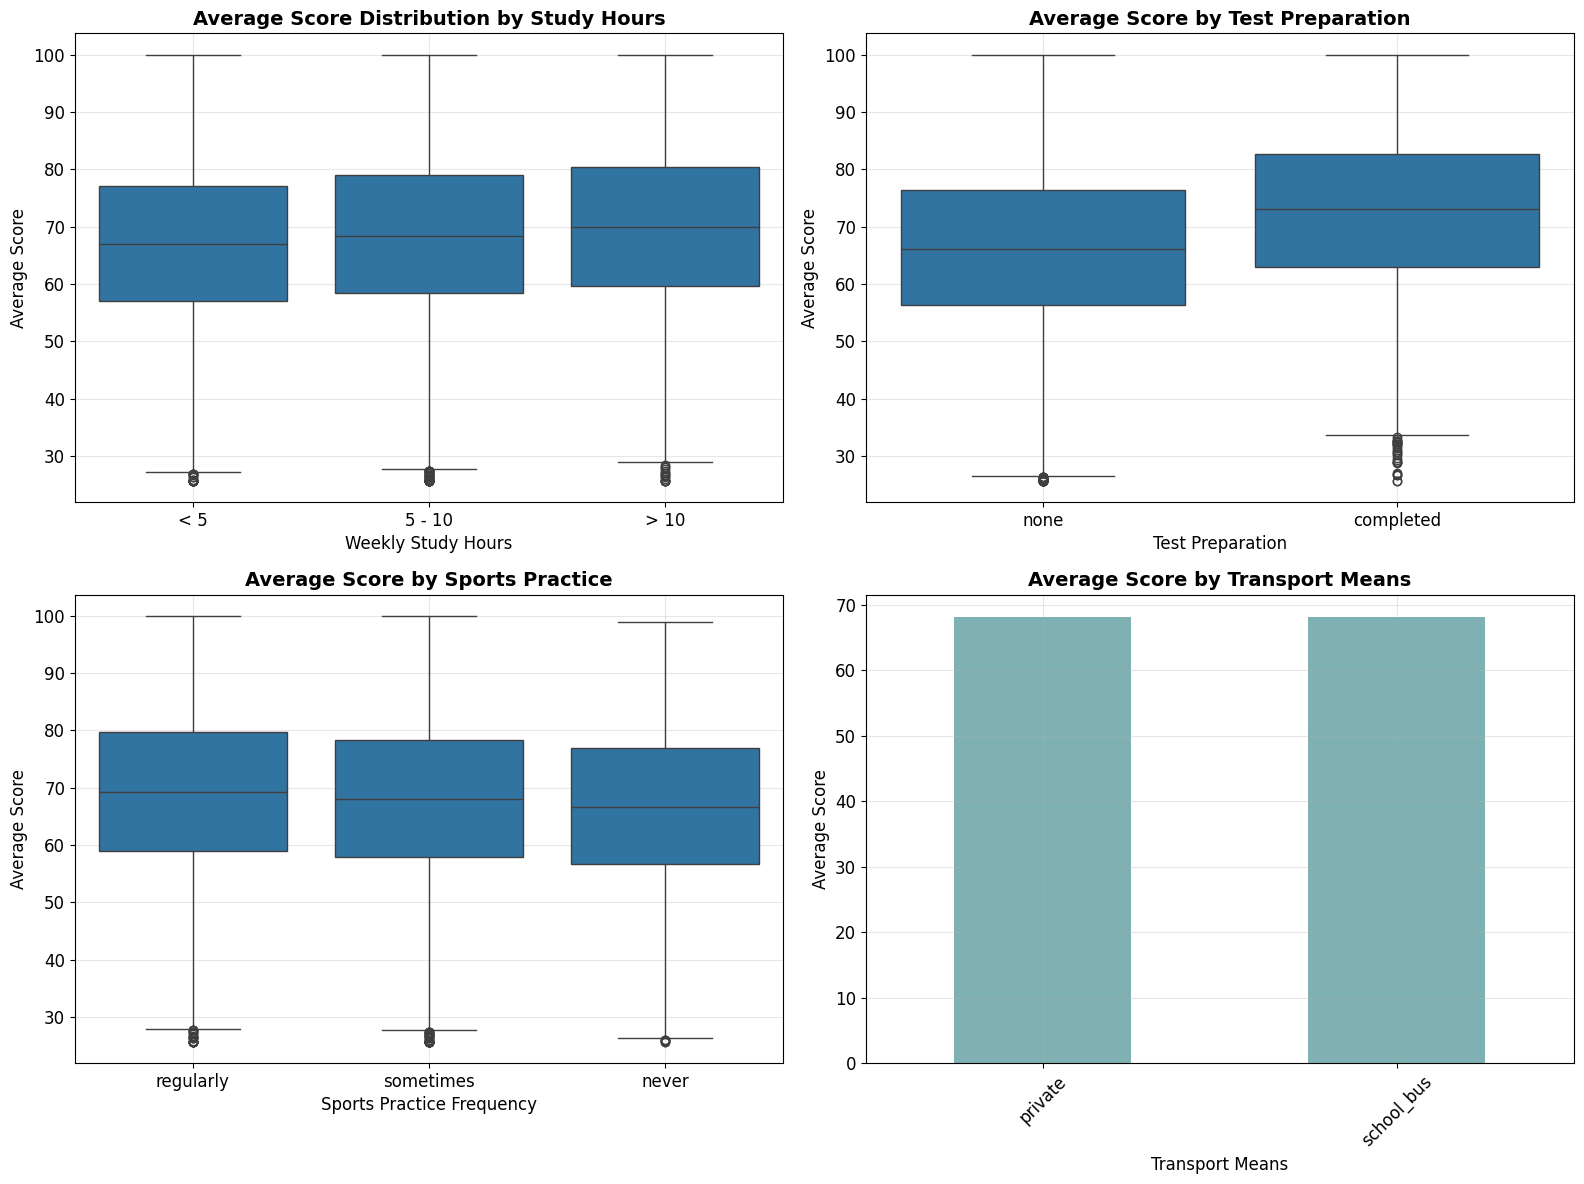

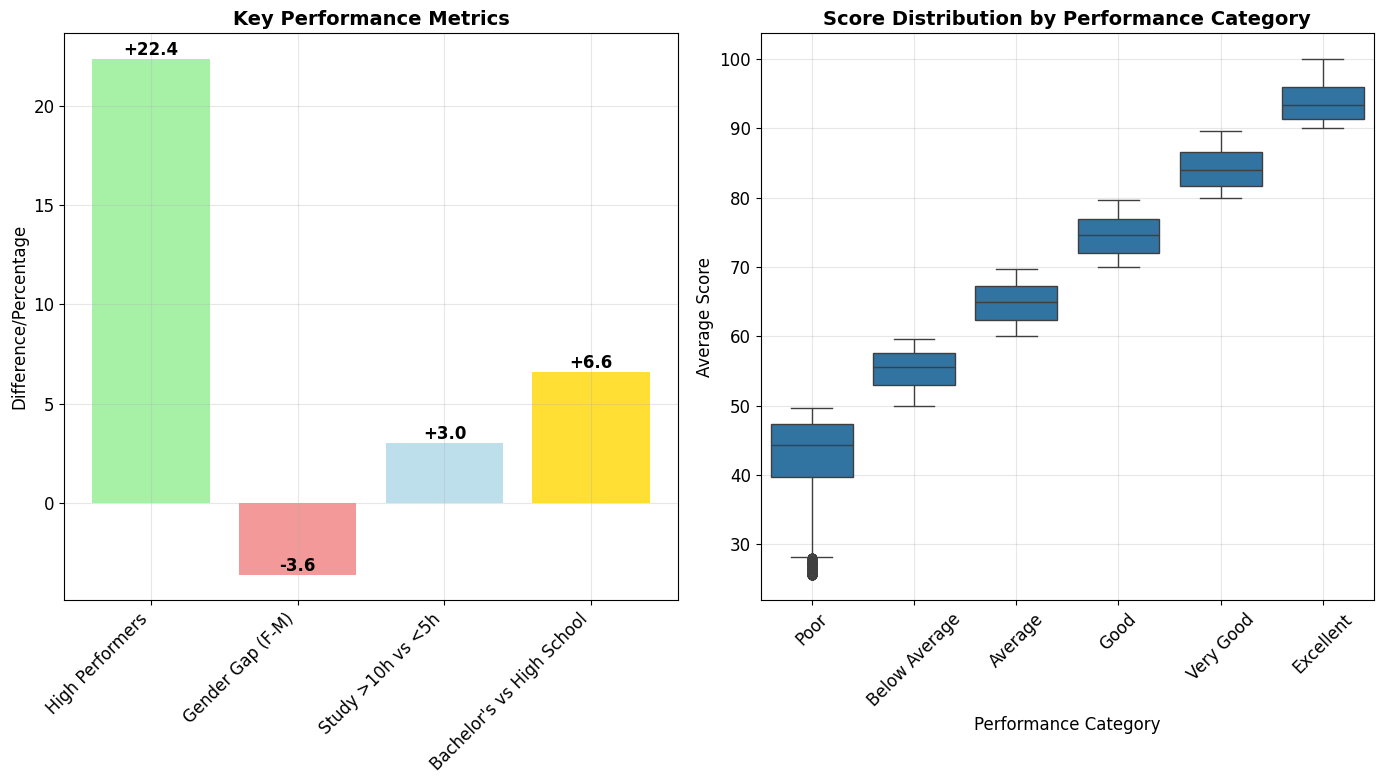

Visualizations saved to: figures/


In [37]:
TARGET = "AverageScore"
print(f"Selected target: {TARGET}")

df['pass_fail'] = (df[TARGET] >= df[TARGET].median()).astype(int)
print(f"Classification target created. Class distribution: {df['pass_fail'].value_counts().to_dict()}")

plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16, 'axes.titlesize': 14})

plt.figure(figsize=(15, 5))
for i, subject in enumerate(score_cols, 1):
    plt.subplot(1, 3, i)
    plt.hist(df[subject], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'{subject.replace("Score", "")} Score Distribution')
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'score_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
gender_avg = df.groupby('Gender')['AverageScore'].mean()
colors = ['lightcoral', 'lightblue']
bars = plt.bar(gender_avg.index, gender_avg.values, color=colors, alpha=0.8)
plt.title('Average Score by Gender', fontweight='bold')
plt.ylabel('Average Score')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
performance_counts = df['PerformanceCategory'].value_counts()
plt.pie(performance_counts.values, labels=performance_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(performance_counts))))
plt.title('Performance Category Distribution', fontweight='bold')

plt.subplot(2, 3, 3)
study_hours_avg = df.groupby('WklyStudyHours')['AverageScore'].mean().sort_index()
study_order = ['< 5', '5 - 10', '> 10']
study_hours_avg = study_hours_avg.reindex(study_order)
bars = plt.bar(study_hours_avg.index, study_hours_avg.values, color='lightgreen', alpha=0.8)
plt.title('Average Score by Study Hours', fontweight='bold')
plt.ylabel('Average Score')
plt.xlabel('Weekly Study Hours')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
parent_educ_avg = df.groupby('ParentEduc')['AverageScore'].mean().sort_values()
bars = plt.barh(range(len(parent_educ_avg)), parent_educ_avg.values, 
                color='lightsteelblue', alpha=0.8)
plt.yticks(range(len(parent_educ_avg)), parent_educ_avg.index)
plt.title('Average Score by Parent Education', fontweight='bold')
plt.xlabel('Average Score')

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2., 
             f'{width:.1f}', ha='left', va='center', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
ethnic_avg = df.groupby('EthnicGroup')['AverageScore'].mean().sort_values(ascending=False)
bars = plt.bar(ethnic_avg.index, ethnic_avg.values, color='plum', alpha=0.8)
plt.title('Average Score by Ethnic Group', fontweight='bold')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
lunch_avg = df.groupby('LunchType')['AverageScore'].mean()
colors = ['gold', 'lightcoral']
bars = plt.bar(lunch_avg.index, lunch_avg.values, color=colors, alpha=0.8)
plt.title('Average Score by Lunch Type', fontweight='bold')
plt.ylabel('Average Score')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'demographic_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

 
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()


mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(16, 12))


plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='WklyStudyHours', y='AverageScore', order=study_order)
plt.title('Average Score Distribution by Study Hours', fontweight='bold')
plt.xlabel('Weekly Study Hours')
plt.ylabel('Average Score')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='TestPrep', y='AverageScore')
plt.title('Average Score by Test Preparation', fontweight='bold')
plt.xlabel('Test Preparation')
plt.ylabel('Average Score')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='PracticeSport', y='AverageScore')
plt.title('Average Score by Sports Practice', fontweight='bold')
plt.xlabel('Sports Practice Frequency')
plt.ylabel('Average Score')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
transport_avg = df.groupby('TransportMeans')['AverageScore'].mean().sort_values(ascending=False)
transport_avg.plot(kind='bar', color='cadetblue', alpha=0.8)
plt.title('Average Score by Transport Means', fontweight='bold')
plt.xlabel('Transport Means')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'detailed_boxplots.png'), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 8))

high_performers_pct = (df['HighPerformer'].sum() / len(df)) * 100
study_impact = df.groupby('WklyStudyHours')['AverageScore'].mean()
parent_impact = df.groupby('ParentEduc')['AverageScore'].mean()
gender_gap = df.groupby('Gender')['AverageScore'].mean().diff().iloc[-1]

metrics_data = {
    'High Performers': high_performers_pct,
    'Gender Gap (F-M)': gender_gap,
    'Study >10h vs <5h': study_impact['> 10'] - study_impact['< 5'],
    "Bachelor's vs High School": parent_impact["bachelor's degree"] - parent_impact['high school']
}

plt.subplot(1, 2, 1)
colors = ['lightgreen', 'lightcoral', 'lightblue', 'gold']
bars = plt.bar(metrics_data.keys(), metrics_data.values(), color=colors, alpha=0.8)
plt.title('Key Performance Metrics', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Difference/Percentage')
plt.grid(True, alpha=0.3)

for bar, value in zip(bars, metrics_data.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{value:+.1f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
performance_order = ['Poor', 'Below Average', 'Average', 'Good', 'Very Good', 'Excellent']
sns.boxplot(data=df, x='PerformanceCategory', y='AverageScore', order=performance_order)
plt.title('Score Distribution by Performance Category', fontweight='bold', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Performance Category')
plt.ylabel('Average Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'key_insights.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualizations saved to: {FIGURES_DIR}/")

### 7. Preprocessing Pipeline

In [38]:

X = df.drop(columns=[TARGET, 'pass_fail', 'Unnamed: 0'])  
y_reg = df[TARGET]  
y_clf = df['pass_fail']  

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {num_features}")
print(f"Categorical features: {cat_features}")

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

Numeric features: ['NrSiblings', 'MathScore', 'ReadingScore', 'WritingScore', 'TotalScore', 'ScoreBalance', 'HighPerformer', 'WklyStudyHours_Numeric']
Categorical features: ['Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans', 'WklyStudyHours', 'PerformanceCategory', 'StrongestSubject', 'WeakestSubject', 'SiblingCategory']


In [39]:

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42, stratify=df['pass_fail'])

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=df['pass_fail'])

print(f"Regression - Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Classification - Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")

Regression - Train: (24512, 22), Test: (6129, 22)
Classification - Train: (24512, 22), Test: (6129, 22)


###  8. Train/Test Split Completed

In [40]:

regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

classification_models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42)
}

reg_results = []
for name, model in regression_models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train_reg, y_train_reg)
    y_pred = pipeline.predict(X_test_reg)
    
    reg_results.append([
        name,
        r2_score(y_test_reg, y_pred),
        mean_squared_error(y_test_reg, y_pred),
        mean_absolute_error(y_test_reg, y_pred)
    ])

clf_results = []
for name, model in classification_models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train_clf, y_train_clf)
    y_pred = pipeline.predict(X_test_clf)
    y_pred_proba = pipeline.predict_proba(X_test_clf)[:, 1] if hasattr(model, 'predict_proba') else None
    
    clf_results.append([
        name,
        accuracy_score(y_test_clf, y_pred),
        precision_score(y_test_clf, y_pred),
        recall_score(y_test_clf, y_pred),
        f1_score(y_test_clf, y_pred)
    ])

###  9. Model Training Completed

In [41]:
reg_results_df = pd.DataFrame(reg_results, 
                            columns=["Model", "R2 Score", "MSE", "MAE"])
print("\n=== REGRESSION RESULTS ===")
display(reg_results_df)
  
clf_results_df = pd.DataFrame(clf_results,
                            columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print("\n=== CLASSIFICATION RESULTS ===")
display(clf_results_df)

best_reg_model = reg_results_df.loc[reg_results_df['R2 Score'].idxmax()]
best_clf_model = clf_results_df.loc[clf_results_df['Accuracy'].idxmax()]

print(f"\nBest Regression Model: {best_reg_model['Model']} (R2: {best_reg_model['R2 Score']:.4f})")
print(f"Best Classification Model: {best_clf_model['Model']} (Accuracy: {best_clf_model['Accuracy']:.4f})")


=== REGRESSION RESULTS ===


,Model,R2 Score,MSE,MAE
0,Linear Regression,1.0,2.053298e-28,1.073639e-14
1,Ridge Regression,1.0,4.790564e-07,5.682992e-04
2,Lasso Regression,1.0,1.001614e-04,8.120807e-03
3,Decision Tree,1.0,1.812875e-05,1.087725e-04
4,Random Forest,1.0,1.500018e-05,1.743079e-04



=== CLASSIFICATION RESULTS ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.999674,0.999677,0.999677,0.999677
1,Decision Tree Classifier,1.000000,1.000000,1.000000,1.000000
2,Random Forest Classifier,1.000000,1.000000,1.000000,1.000000



Best Regression Model: Linear Regression (R2: 1.0000)
Best Classification Model: Decision Tree Classifier (Accuracy: 1.0000)


### 11. SHAP Interpretability

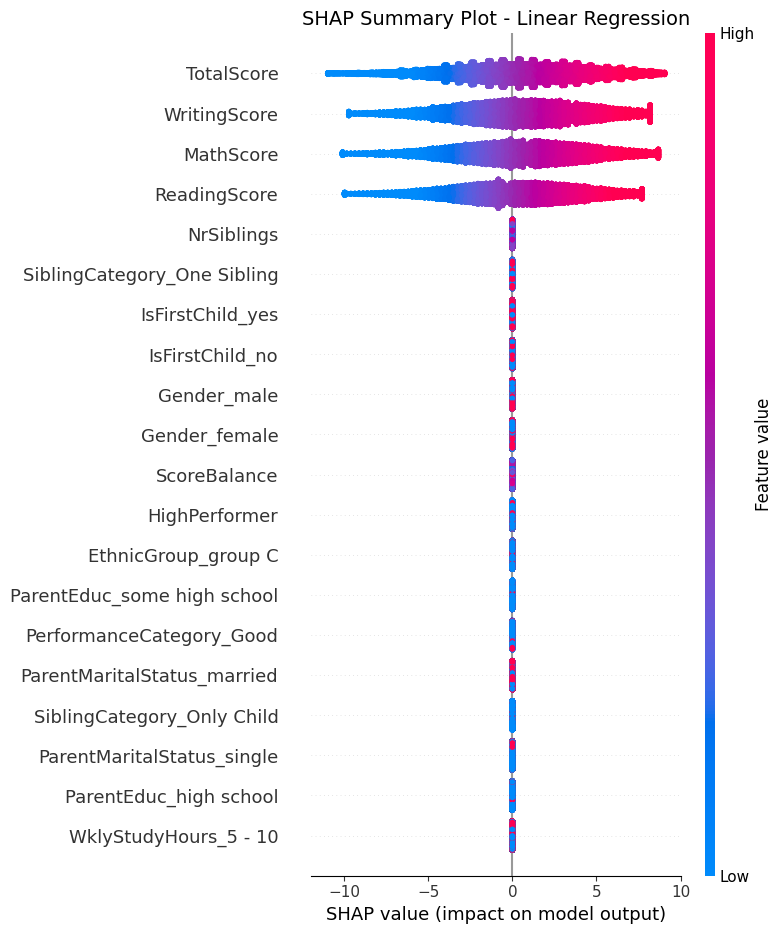


Top 10 Most Important Features (SHAP):


,feature,importance
4,TotalScore,3.182735e+00
3,WritingScore,3.078153e+00
1,MathScore,3.063437e+00
2,ReadingScore,2.930822e+00
0,NrSiblings,4.268568e-15
53,SiblingCategory_One Sibling,2.408454e-15
33,IsFirstChild_yes,2.131623e-15
32,IsFirstChild_no,2.022620e-15
9,Gender_male,1.666297e-15
8,Gender_female,1.555210e-15


In [42]:

best_reg_model_name = best_reg_model['Model']
best_reg_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', regression_models[best_reg_model_name])
])
best_reg_pipeline.fit(X_train_reg, y_train_reg)

X_processed = best_reg_pipeline.named_steps['preprocess'].transform(X_train_reg)
feature_names = (num_features + 
                list(best_reg_pipeline.named_steps['preprocess']
                    .named_transformers_['cat']
                    .named_steps['encoder']
                    .get_feature_names_out(cat_features)))


if hasattr(best_reg_pipeline.named_steps['model'], 'coef_'):
 
    explainer = shap.LinearExplainer(best_reg_pipeline.named_steps['model'], X_processed)
    shap_values = explainer.shap_values(X_processed)
else:
    
    explainer = shap.TreeExplainer(best_reg_pipeline.named_steps['model'])
    shap_values = explainer.shap_values(X_processed)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_processed, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary Plot - {best_reg_model_name}')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

shap_importance = np.abs(shap_values).mean(0)
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (SHAP):")
display(feature_importance_df.head(10))


### 12. Final Predictions

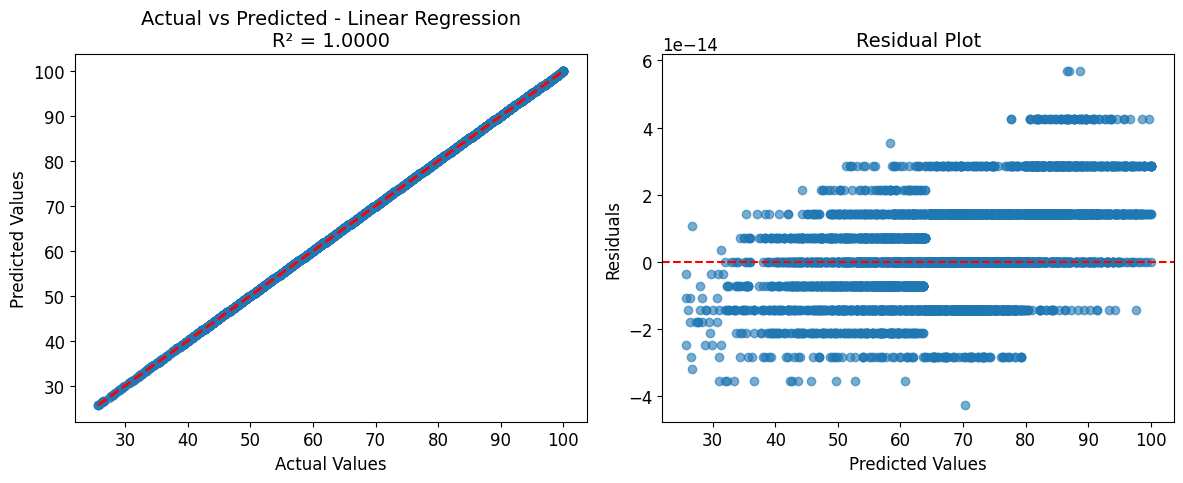

In [43]:
best_reg_predictions = best_reg_pipeline.predict(X_test_reg)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, best_reg_predictions, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted - {best_reg_model_name}\nR² = {best_reg_model["R2 Score"]:.4f}')

plt.subplot(1, 2, 2)
residuals = y_test_reg - best_reg_predictions
plt.scatter(best_reg_predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'final_predictions.png'), dpi=300, bbox_inches='tight')
plt.show()


###  13. Save Model & Pipeline

In [44]:

best_reg_model_path = os.path.join(OUTPUT_DIR, 'best_regression_model.pkl')
joblib.dump(best_reg_pipeline, best_reg_model_path)


preprocessor_path = os.path.join(OUTPUT_DIR, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)

results_path = os.path.join(OUTPUT_DIR, 'model_results.csv')
all_results = pd.concat([
    reg_results_df.assign(task='regression'),
    clf_results_df.assign(task='classification')
], ignore_index=True)
all_results.to_csv(results_path, index=False)

print(f"Models saved to: {best_reg_model_path}")
print(f"Preprocessor saved to: {preprocessor_path}")
print(f"Results saved to: {results_path}")


Models saved to: outputs\best_regression_model.pkl
Preprocessor saved to: outputs\preprocessor.pkl
Results saved to: outputs\model_results.csv


### 14. Export Results

In [45]:
final_summary = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_shape': df.shape,
    'best_regression_model': best_reg_model['Model'],
    'best_regression_r2': best_reg_model['R2 Score'],
    'best_classification_model': best_clf_model['Model'],
    'best_classification_accuracy': best_clf_model['Accuracy'],
    'top_features': feature_importance_df.head(5)['feature'].tolist()
}

summary_path = os.path.join(OUTPUT_DIR, 'project_summary.txt')
with open(summary_path, 'w') as f:
    for key, value in final_summary.items():
        f.write(f"{key}: {value}\n")

feature_importance_path = os.path.join(OUTPUT_DIR, 'feature_importance.csv')
feature_importance_df.to_csv(feature_importance_path, index=False)

print(f"- Project summary: {summary_path}")
print(f"- Feature importance: {feature_importance_path}")
print(f"- All visualizations: {FIGURES_DIR}/")


- Project summary: outputs\project_summary.txt
- Feature importance: outputs\feature_importance.csv
- All visualizations: figures/


### 15. Final Summary

In [46]:


print(f"\n📊 DATASET SUMMARY:")
print(f"   • Original shape: {df.shape}")
print(f"   • Features: {len(X.columns)}")
print(f"   • Target: {TARGET}")

print(f"\n🏆 BEST MODELS:")
print(f"   • Regression: {best_reg_model['Model']} (R²: {best_reg_model['R2 Score']:.4f})")
print(f"   • Classification: {best_clf_model['Model']} (Accuracy: {best_clf_model['Accuracy']:.4f})")

print(f"\n🔍 KEY INSIGHTS:")
print(f"   • Top 3 features: {', '.join(feature_importance_df.head(3)['feature'].tolist())}")
print(f"   • High performers: {df['HighPerformer'].sum()} students ({df['HighPerformer'].mean()*100:.1f}%)")

print(f"\n💾 OUTPUTS SAVED:")
print(f"   • Cleaned data: {OUTPUT_DIR}/cleaned_student.csv")
print(f"   • Engineered data: {OUTPUT_DIR}/engineered_student.csv")
print(f"   • Trained model: {OUTPUT_DIR}/best_regression_model.pkl")
print(f"   • Visualizations: {FIGURES_DIR}/")




📊 DATASET SUMMARY:
   • Original shape: (30641, 25)
   • Features: 22
   • Target: AverageScore

🏆 BEST MODELS:
   • Regression: Linear Regression (R²: 1.0000)
   • Classification: Decision Tree Classifier (Accuracy: 1.0000)

🔍 KEY INSIGHTS:
   • Top 3 features: TotalScore, WritingScore, MathScore
   • High performers: 6861 students (22.4%)

💾 OUTPUTS SAVED:
   • Cleaned data: outputs/cleaned_student.csv
   • Engineered data: outputs/engineered_student.csv
   • Trained model: outputs/best_regression_model.pkl
   • Visualizations: figures/
